In [1382]:

from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [1383]:
df = pd.read_csv('WineQT.csv') 
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [1384]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [1385]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [1386]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [1387]:
df.duplicated().sum()

np.int64(0)

In [1388]:
df.drop('Id',axis=1,inplace=True)

In [1389]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

<Axes: >

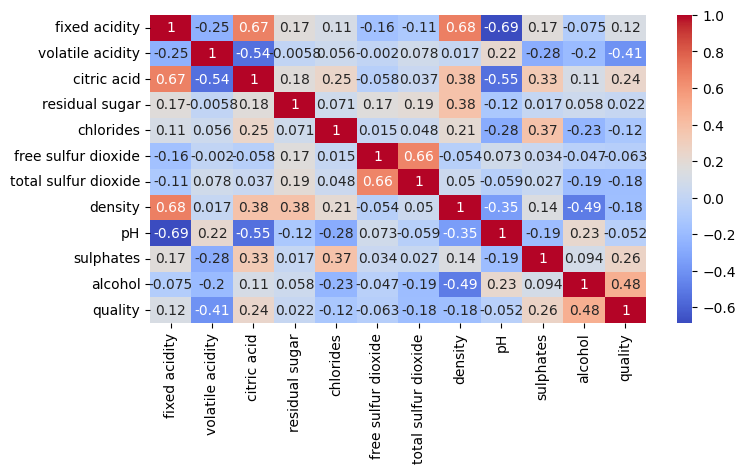

In [1390]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(),cmap='coolwarm',annot=True)

<Axes: xlabel='quality', ylabel='count'>

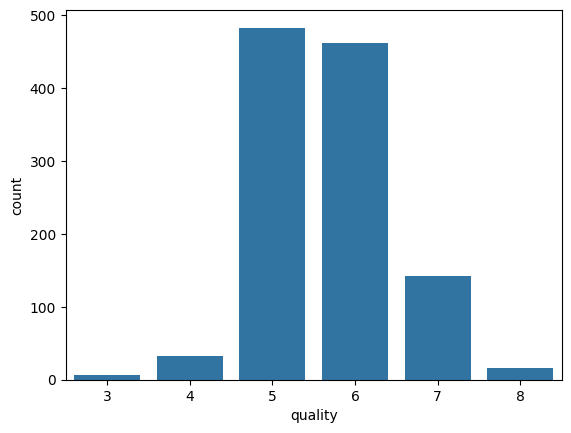

In [1391]:
import seaborn as sns
sns.countplot(x='quality',data=df)

In [1392]:
x = df.drop('quality',axis=1)  # pick a few features
y= df[['quality']]
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2


In [1393]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1138,6
1139,6
1140,5
1141,6


In [ ]:
from collections import Counter
print(Counter(y))

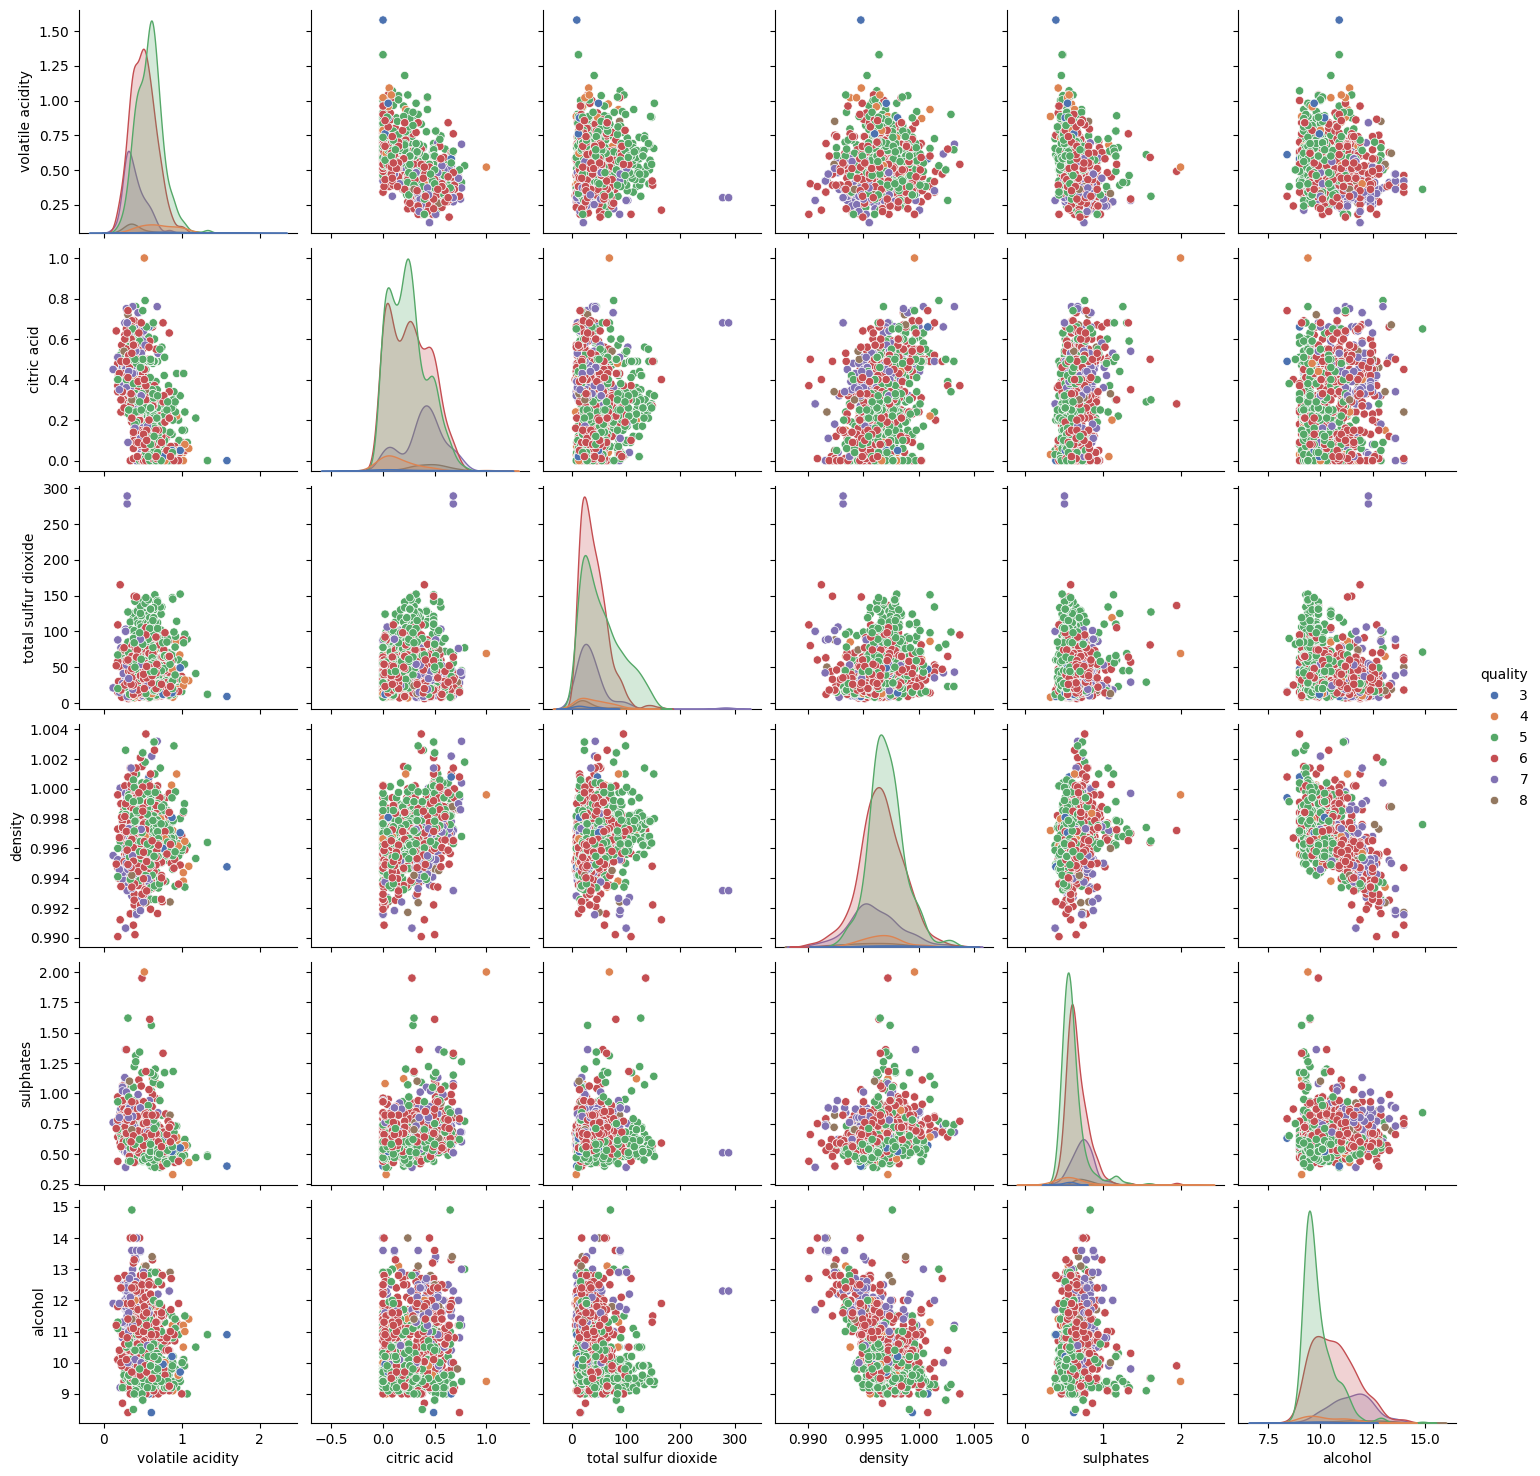

In [1394]:
sns.pairplot(df[[ 'volatile acidity', 'citric acid',
         'total sulfur dioxide', 'density',
       'sulphates', 'alcohol', 'quality']],hue='quality',palette='deep')

In [1395]:
y['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [1396]:
from sklearn.preprocessing import LabelEncoder
ord=LabelEncoder()
y=ord.fit_transform(y)
y=pd.DataFrame(y,columns=['quality'])
y

,quality
0,2
1,2
2,2
3,3
4,2
...,...
1138,3
1139,3
1140,2
1141,3


In [1397]:
X_scaled = MinMaxScaler().fit_transform(x)
x_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

In [1398]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42,
    sampling_strategy='not majority',
)
x_res, y_res = ros.fit_resample(x_train, y_train)

<Axes: xlabel='quality', ylabel='count'>

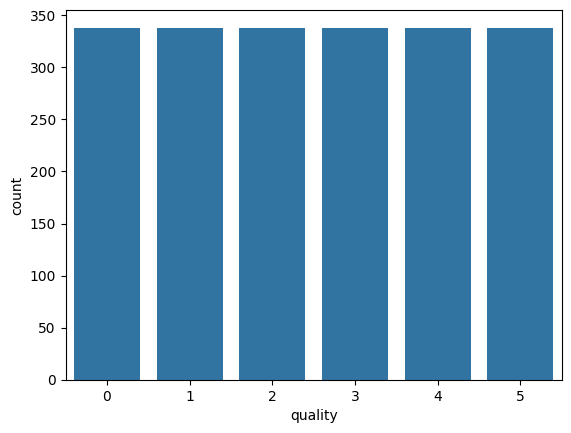

In [1399]:
sns.countplot(x='quality',data=y_res)

In [1400]:
# from imblearn.over_sampling import SMOTE
# sample=SMOTE(random_state=42,k_neighbors=2)
# x_train_res,y_train_res=sample.fit_resample(x_train,y_train)

In [1401]:
# sns.countplot(x='quality',data=y_train_res)

In [1402]:

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42,class_weight='balanced')
model.fit(x_res, y_res)

# from xgboost import XGBClassifier

# model = XGBClassifier(
#     objective='multi:softmax',
#     num_class=len(set(y_train)),
#     eval_metric='mlogloss',
#     random_state=42,
#     scale_pos_weight=None  # auto-balance
# )
# model.fit(x_train_res, y_train_res)


y_pred = model.predict(X_test)
y_pred

array([2, 4, 2, 2, 3, 2, 2, 3, 4, 2, 3, 2, 3, 4, 4, 4, 2, 3, 3, 4, 2, 2,
       3, 3, 2, 3, 4, 3, 3, 3, 3, 3, 2, 2, 2, 3, 2, 4, 2, 4, 2, 4, 3, 2,
       3, 3, 3, 4, 3, 2, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2, 3, 3, 2, 3,
       3, 4, 2, 3, 2, 3, 4, 2, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2, 3, 2, 2, 3,
       4, 2, 2, 2, 2, 2, 4, 3, 3, 2, 2, 3, 2, 2, 3, 3, 2, 3, 3, 3, 3, 3,
       2, 4, 2, 1, 2, 3, 3, 2, 3, 3, 3, 4, 4, 3, 3, 3, 2, 2, 2, 4, 2, 2,
       2, 3, 4, 3, 2, 2, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 2, 4, 2, 2, 2, 0,
       3, 3, 4, 2, 3, 3, 2, 2, 3, 2, 3, 2, 4, 4, 2, 2, 2, 4, 2, 2, 2, 3,
       2, 3, 4, 2, 3, 3, 3, 2, 2, 2, 3, 3, 2, 2, 2, 2, 3, 4, 3, 2, 2, 2,
       2, 5, 3, 3, 2, 3, 3, 3, 3, 2, 2, 2, 4, 2, 3, 3, 2, 3, 2, 2, 3, 2,
       2, 3, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 4, 4, 2, 4, 2,
       3, 2, 2, 2, 3, 4, 2, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 3, 2, 2, 2, 3,
       3, 2, 3, 4, 2, 4, 2, 3, 2, 2, 2, 2, 3, 4, 2, 4, 4, 2, 3, 3, 3, 4,
       3, 3, 4, 2, 4, 3, 3, 2, 3, 2, 3, 3, 4, 2, 4,

In [1403]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=y_pred
res.reset_index()
res

,actual,predicted
629,3,2
170,4,4
154,2,2
72,2,2
236,4,3
...,...,...
474,3,3
231,3,2
550,3,3
983,2,2


Accuracy: 0.673469387755102
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        10
           2       0.73      0.82      0.78       145
           3       0.67      0.63      0.65       138
           4       0.50      0.56      0.53        43
           5       1.00      0.20      0.33         5

    accuracy                           0.67       343
   macro avg       0.48      0.37      0.38       343
weighted avg       0.66      0.67      0.66       343



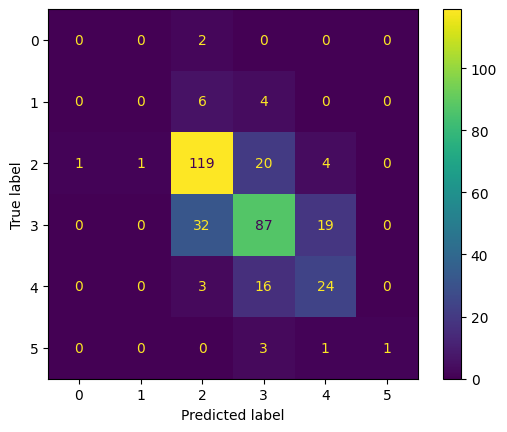

In [1404]:
from sklearn.metrics import ConfusionMatrixDisplay
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()